# KLDM-New: Step-by-Step Pipeline Walkthrough

This notebook walks through the full `kldm_new` pipeline — a **Kinetic Langevin Diffusion Model**
reimplemented natively in the MatterGen framework.

We use the **MP-20** dataset (Materials Project, 20 atoms max) and cover:

1. **Data loading** — MatterGen's `CrystalDataset` + `CrystDataModule`
2. **Corruption** — TDM (kinetic Langevin on pos+vel) + LatticeVPSDE (cell 3×3)
3. **Score model** — `CSPVCellNet` GNN architecture
4. **Loss** — wrapped-normal target (vel) + denoising score matching (cell)
5. **Training loop** — via the `LitKLDM` Lightning module
6. **Sampling** — Predictor–Corrector reverse-time loop
7. **Structure conversion** — sampled tensors → pymatgen `Structure`

## 1. Data Loading

We load MP-20 directly from the processed cache using MatterGen's
`CrystalDataset` and `CrystDataModule`. Each sample is a `ChemGraph`
with `pos` (fractional, ∈[0,1)), `cell` (3×3 Å), `atomic_numbers`, and `num_atoms`.

In [1]:
import os

os.chdir("/workspace")

from omegaconf import OmegaConf
from mattergen.common.data.dataset import CrystalDataset
from mattergen.common.data.datamodule import CrystDataModule

DATA_ROOT = "data/mp_20/processed"

train_ds = CrystalDataset.from_cache_path(f"{DATA_ROOT}/train")
val_ds = CrystalDataset.from_cache_path(f"{DATA_ROOT}/val")

print(f"Train: {len(train_ds)} structures")
print(f"Val:   {len(val_ds)} structures")

/workspace/.venv/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


MODELS_PROJECT_ROOT: /workspace/.venv/lib/python3.12/site-packages/mattergen
Train: 27136 structures
Val:   9047 structures


In [2]:
# Inspect a single sample
sample = train_ds[0]
print(f"Type:           {type(sample).__name__}")
print(f"pos:            {sample.pos.shape}  (fractional coords)")
print(f"cell:           {sample.cell.shape}  (lattice matrix, Å)")
print(f"atomic_numbers: {sample.atomic_numbers.shape}")
print(f"num_atoms:      {sample.num_atoms}")
print(f"\ncell matrix:\n{sample.cell.squeeze(0)}")

Type:           ChemGraph
pos:            torch.Size([12, 3])  (fractional coords)
cell:           torch.Size([1, 3, 3])  (lattice matrix, Å)
atomic_numbers: torch.Size([12])
num_atoms:      12

cell matrix:
tensor([[ 0.6031, -2.9686, -0.0000],
        [-0.0000, -0.0000,  5.6371],
        [-7.6079, -0.0000, -2.4004]])


In [3]:
# Create a DataModule with MatterGen's collation
dm = CrystDataModule(
    train_dataset=train_ds,
    val_dataset=val_ds,
    num_workers=OmegaConf.create({"train": 0, "val": 0, "test": 0}),
    batch_size=OmegaConf.create({"train": 32, "val": 32, "test": 32}),
)

train_dl = dm.train_dataloader()
batch = next(iter(train_dl))

print(f"Batch type:     {type(batch).__name__}")
print(f"batch_size:     {batch.num_graphs}")
print(f"pos:            {batch.pos.shape}")
print(f"cell:           {batch.cell.shape}")
print(f"atomic_numbers: {batch.atomic_numbers.shape}")
print(f"num_atoms:      {batch.num_atoms}")
print(f"batch idx:      {batch.batch}")

Batch type:     ChemGraphBatch
batch_size:     32
pos:            torch.Size([376, 3])
cell:           torch.Size([32, 3, 3])
atomic_numbers: torch.Size([376])
num_atoms:      tensor([10,  9, 10, 12,  8, 14, 14, 20,  6,  2,  5, 14,  4, 16,  8,  5, 12, 12,
        12,  7, 16, 15, 16, 14, 20, 20, 18, 12, 13,  8, 12, 12])
batch idx:      tensor([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,  3,  3,  3,
         3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  5,  5,  5,  5,  5,
         5,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,  6,  6,  6,
         6,  6,  6,  6,  6,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,
         7,  7,  7,  7,  7,  7,  7,  8,  8,  8,  8,  8,  8,  9,  9, 10, 10, 10,
        10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 12, 12,
        12, 12, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
        14, 14, 14, 14,

## 2. Corruption: TDM + LatticeVPSDE

KLDM uses two coupled corruption processes:

| Field | SDE | Representation | Prior |
|-------|-----|----------------|-------|
| **pos** (fractional coords) | Kinetic Langevin (TDM) | `(N, 3)` on torus [0,1) | Uniform |
| **vel** (auxiliary velocity) | Kinetic Langevin (TDM) | `(N, 3)` | N(0, I) |
| **cell** (lattice matrix) | VP-SDE (LatticeVPSDE) | `(B, 3, 3)` | N(μ(n), σ²(n)) |

The key novelty: position and velocity are **coupled** — the position marginal
at time *t* depends on the clean velocity *v₀*, not just *pos₀*.

### 2a. Build the corruption

In [4]:
from kldm_new.diffusion.tdm import KineticLangevinSDE
from kldm_new.diffusion.lattice_sde import LatticeVPSDE
from kldm_new.diffusion.corruption import KLDMMultiCorruption

# TDM for fractional coordinates (period = 1.0, terminal time = 2.0)
tdm = KineticLangevinSDE(
    scale_pos=1.0,  # period of the torus (fractional coords)
    tf=2.0,  # terminal diffusion time T
    k_wn_score=13,  # periodic images for wrapped-normal score
    simplified_parameterization=True,
)

# VP-SDE for lattice cell matrix (atom-count-aware prior)
cell_sde = LatticeVPSDE(
    beta_min=0.1,
    beta_max=20.0,
    limit_density=0.05,  # atoms/ų — sets prior mean
)

# Combined multi-corruption
corruption = KLDMMultiCorruption(pos_sde=tdm, cell_sde=cell_sde)

print(f"Corrupted fields: {corruption.corrupted_fields}")
print(f"Terminal time T:  {corruption.T}")

Corrupted fields: ['pos', 'vel', 'cell']
Terminal time T:  2.0


### 2b. Visualize the forward corruption process

We add a zero velocity field to the clean batch, then corrupt at several time steps.

vel field added: torch.Size([376, 3])


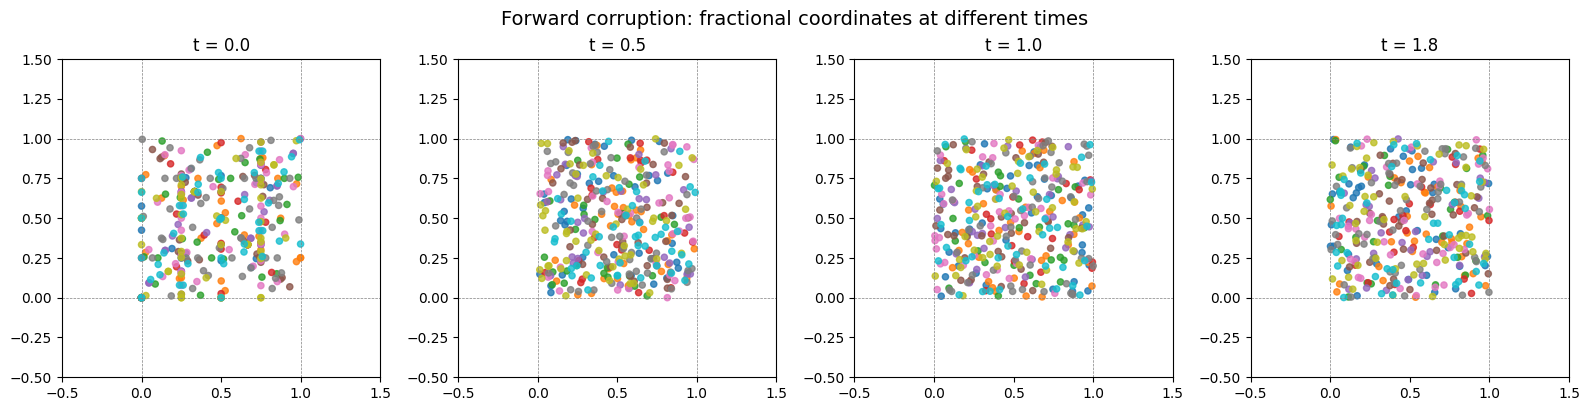

In [5]:
import torch
import matplotlib.pyplot as plt
from kldm_new.data import add_velocity

batch_v = add_velocity(batch)
print(f"vel field added: {batch_v['vel'].shape}")

# Corrupt at different times
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
times = [0.0, 0.5, 1.0, 1.8]

for ax, t_val in zip(axes, times):
    if t_val == 0.0:
        noisy = batch_v
    else:
        t = torch.full((batch.num_graphs, 1), t_val)
        noisy = corruption.sample_marginal(batch_v, t)

    pos = noisy["pos"].detach().numpy()
    ax.scatter(pos[:, 0], pos[:, 1], c=batch.batch.numpy(), cmap="tab10", s=20, alpha=0.8)
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_aspect("equal")
    ax.set_title(f"t = {t_val:.1f}")
    ax.axhline(0, color="gray", lw=0.5, ls="--")
    ax.axhline(1, color="gray", lw=0.5, ls="--")
    ax.axvline(0, color="gray", lw=0.5, ls="--")
    ax.axvline(1, color="gray", lw=0.5, ls="--")

fig.suptitle("Forward corruption: fractional coordinates at different times", fontsize=14)
plt.tight_layout()
plt.show()

### 2c. TDM marginal distributions

The TDM velocity marginal is Gaussian: $v_t \sim \mathcal{N}(e^{-t} v_0,\; (1-e^{-2t}) I)$.

The displacement marginal is wrapped-normal with:
- $\mu_r = (1 - e^{-t}) v_0$
- $\sigma_r^2 = 2t - 3 + 4e^{-t} - e^{-2t}$

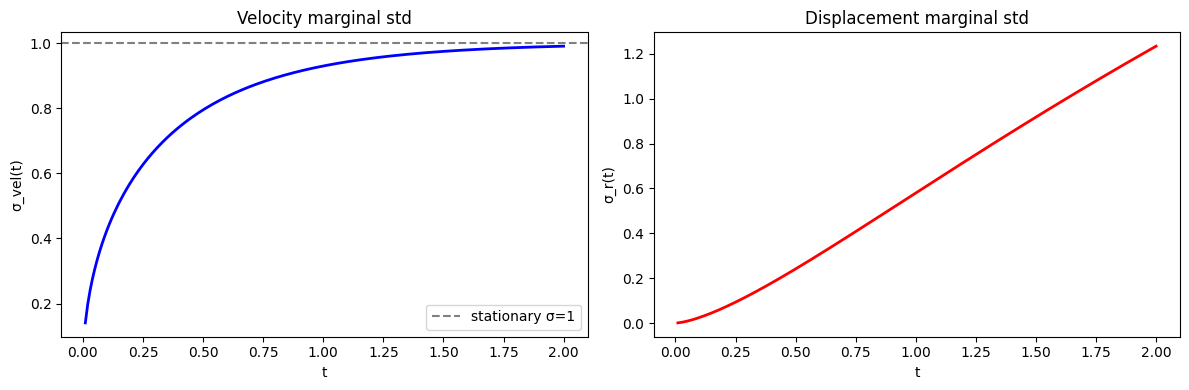

In [6]:
import numpy as np

ts = np.linspace(0.01, 2.0, 200)

# Velocity std
vel_std = np.sqrt(1 - np.exp(-2 * ts))

# Displacement std
disp_std = np.sqrt(np.clip(2 * ts - 3 + 4 * np.exp(-ts) - np.exp(-2 * ts), 1e-12, None))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ts, vel_std, "b-", lw=2)
ax1.set_xlabel("t")
ax1.set_ylabel("σ_vel(t)")
ax1.set_title("Velocity marginal std")
ax1.axhline(1.0, color="gray", ls="--", label="stationary σ=1")
ax1.legend()

ax2.plot(ts, disp_std, "r-", lw=2)
ax2.set_xlabel("t")
ax2.set_ylabel("σ_r(t)")
ax2.set_title("Displacement marginal std")

plt.tight_layout()
plt.show()

## 3. Score Model: CSPVCellNet

The score model is a GNN (`CSPVCellNet`) that takes a noisy crystal and predicts:
- **vel score** `(N, 3)` — per-atom, zero centre-of-gravity
- **cell score** `(B, 3, 3)` — per-graph (score × std, i.e. predicted noise)

Architecture:
1. Atom embedding + Fourier time embedding → node features
2. Message passing via `CSPVCellLayer`: edge features from `[h_i, h_j, cell_flat, v_proj(Δv), sin_emb(Δpos)]`
3. Readout: `out_vel` (per-atom MLP), `out_cell` (graph-level via scatter → linear)

In [7]:
from kldm_new.nn.arch import CSPVCellNet
from kldm_new.model import KLDMScoreModel

net = CSPVCellNet(
    hidden_dim=128,
    time_dim=128,
    num_layers=4,
    h_dim=100,  # num atom types (periodic table)
    num_freqs=10,  # sinusoidal frequencies for distance embedding
    ln=True,  # layer normalization
    pred_vel=True,
    pred_cell=True,
    zero_cog=True,  # enforce zero centre-of-gravity on velocity output
)

# Wrap in KLDMScoreModel (handles edge construction)
score_model = KLDMScoreModel(
    net=net,
    cutoff=0.5,  # radius cutoff in fractional coordinate units
    max_neighbors=20,
)

n_params = sum(p.numel() for p in score_model.parameters())
print(f"Score model parameters: {n_params:,}")
print(f"\nArchitecture:\n{net}")

Score model parameters: 502,336

Architecture:
CSPVCellNet(
  (act_fn): SiLU()
  (node_embedding): Embedding(101, 128)
  (atom_latent_emb): Linear(in_features=256, out_features=128, bias=True)
  (dis_emb): SinEmbedding()
  (time_emb): FourierEmbedding(
    (linear): Linear(in_features=128, out_features=128, bias=True)
  )
  (layers): ModuleList(
    (0-3): 4 x CSPVCellLayer(
      (dis_emb): SinEmbedding()
      (v_proj): Linear(in_features=3, out_features=20, bias=True)
      (edge_mlp): Sequential(
        (0): Linear(in_features=305, out_features=128, bias=True)
        (1): SiLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): SiLU()
      )
      (node_mlp): Sequential(
        (0): Linear(in_features=256, out_features=128, bias=True)
        (1): SiLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): SiLU()
      )
      (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
  )
  (final_layer_norm)

In [8]:
# Forward pass on a noisy batch
t = torch.rand(batch.num_graphs, 1) * 1.9 + 0.1  # t ∈ (0.1, 2.0]
noisy_batch = corruption.sample_marginal(batch_v, t)

with torch.no_grad():
    out = score_model(noisy_batch, t)

print(f"Input:")
print(f"  pos:  {noisy_batch['pos'].shape}")
print(f"  vel:  {noisy_batch['vel'].shape}")
print(f"  cell: {noisy_batch['cell'].shape}")
print(f"\nOutput:")
print(f"  vel score:  {out['vel'].shape}  (per-atom)")
print(f"  cell score: {out['cell'].shape}  (per-graph)")

# Verify zero-CoG constraint
from torch_scatter import scatter_mean

cog = scatter_mean(out["vel"], batch.batch, dim=0)
print(f"\nVelocity CoG (should be ~0): {cog.abs().max().item():.2e}")

Input:
  pos:  torch.Size([376, 3])
  vel:  torch.Size([376, 3])
  cell: torch.Size([32, 3, 3])

Output:
  vel score:  torch.Size([376, 3])  (per-atom)
  cell score: torch.Size([32, 3, 3])  (per-graph)

Velocity CoG (should be ~0): 2.55e-08


## 4. Loss Function

`KLDMLoss` computes two terms:

| Component | Target | Loss |
|-----------|--------|------|
| **Velocity (TDM)** | $\nabla_r \log p_{WN}(r \mid \mu_r, \sigma_r)$ × prefactor / √σ_norm | MSE |
| **Cell (DSM)** | $-\varepsilon$ (the noise that was added) | MSE |

The TDM target uses the **wrapped-normal score** — the score of a normal distribution
wrapped on the torus, computed by summing over periodic images.

In [9]:
from kldm_new.diffusion.loss import KLDMLoss

loss_fn = KLDMLoss(weight_vel=1.0, weight_cell=1.0)

# Compute loss on the noisy batch
score_model.train()
out = score_model(noisy_batch, t)

total_loss, loss_dict = loss_fn(
    multi_corruption=corruption,
    batch=batch_v,
    noisy_batch=noisy_batch,
    score_model_output=out,
    t=t,
)

print(f"Loss breakdown:")
for k, v in loss_dict.items():
    print(f"  {k:8s}: {v:.4f}")

# Verify gradients flow
total_loss.backward()
grad_norm = sum(p.grad.norm().item() for p in score_model.parameters() if p.grad is not None)
print(f"\nGradient norm: {grad_norm:.4f}")

Loss breakdown:
  vel     : 0.3327
  cell    : 0.9980
  total   : 1.3307

Gradient norm: 7.2398


### 4a. Wrapped-normal score visualization

The TDM training target comes from $\nabla_x \log p_{WN}(x; \mu, \sigma)$
where $p_{WN}$ is the wrapped-normal distribution on $[0, T)$.

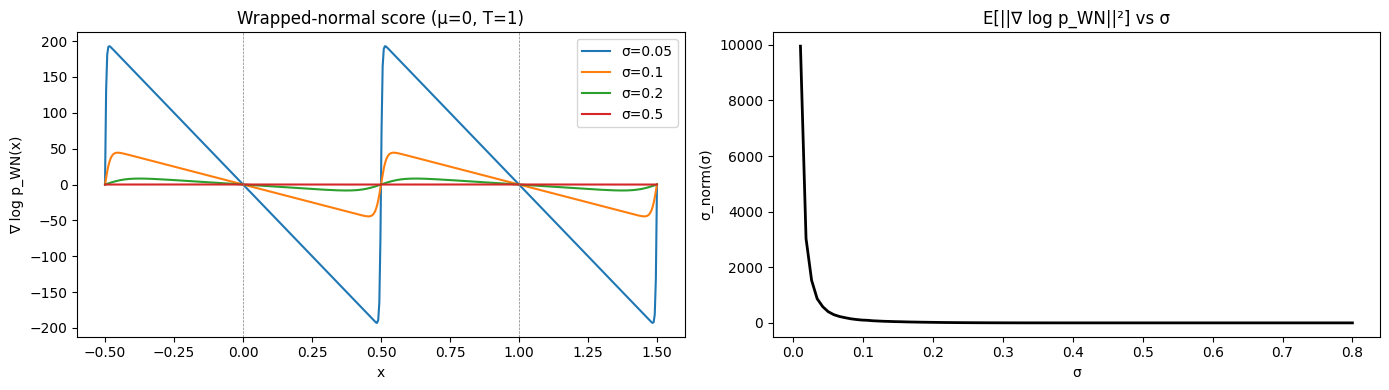

In [10]:
from kldm_new.diffusion import d_log_p_wrapped_normal

x = torch.linspace(-0.5, 1.5, 500)
mu = torch.zeros_like(x)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

for sigma_val in [0.05, 0.1, 0.2, 0.5]:
    sigma = torch.full_like(x, sigma_val)
    score = d_log_p_wrapped_normal(x, mu, sigma, N=13, T=1.0)
    ax1.plot(x.numpy(), score.numpy(), label=f"σ={sigma_val}")

ax1.set_xlabel("x")
ax1.set_ylabel("∇ log p_WN(x)")
ax1.set_title("Wrapped-normal score (μ=0, T=1)")
ax1.legend()
ax1.axvline(0, color="gray", ls="--", lw=0.5)
ax1.axvline(1, color="gray", ls="--", lw=0.5)

# Show sigma_norm vs sigma
from kldm_new.diffusion import sigma_norm

sigmas = torch.linspace(0.01, 0.8, 100)
sn = sigma_norm(sigmas, T=1.0, N=13, sn=5000)

ax2.plot(sigmas.numpy(), sn.numpy(), "k-", lw=2)
ax2.set_xlabel("σ")
ax2.set_ylabel("σ_norm(σ)")
ax2.set_title("E[||∇ log p_WN||²] vs σ")

plt.tight_layout()
plt.show()

## 5. Training with LitKLDM

The `LitKLDM` Lightning module ties everything together:
- `training_step`: sample t → corrupt → predict → loss
- EMA model tracking
- AdamW optimizer

We train for a few steps to verify the pipeline works end-to-end.

In [11]:
from kldm_new.model.lit_module import LitKLDM

# Re-create score model (fresh weights)
net = CSPVCellNet(
    hidden_dim=256,
    time_dim=128,
    num_layers=6,
    h_dim=100,
    num_freqs=10,
)
score_model = KLDMScoreModel(net=net, cutoff=0.5, max_neighbors=20)

lit_module = LitKLDM(
    score_model=score_model,
    multi_corruption=corruption,
    loss_fn=KLDMLoss(weight_vel=1.0, weight_cell=1.0),
    lr=5e-4,
    with_ema=True,
    sampling_N=50,  # fewer steps for demo
    sampling_corrector_steps=1,
)

n_params = sum(p.numel() for p in lit_module.score_model.parameters())
print(f"Model parameters: {n_params:,}")

Model parameters: 2,654,560


In [ ]:
# Manual training loop
optimizer = lit_module.configure_optimizers()
lit_module.train()

losses = {"vel": [], "cell": [], "total": []}
train_dl = dm.train_dataloader()

for step, batch in enumerate(train_dl):
    if step >= 1000:
        break

    optimizer.zero_grad()
    loss = lit_module.training_step(batch, step)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(lit_module.parameters(), max_norm=5.0)
    optimizer.step()

    # Re-compute loss breakdown for logging (training_step only returns scalar)
    losses["total"].append(loss.item())

    if step % 100 == 0:
        print(f"Step {step:4d}: loss = {loss.item():.4f}, vel_loss = {}")

# Plot with smoothing
import numpy as np

totals = np.array(losses["total"])
window = min(50, len(totals) // 4)
smoothed = np.convolve(totals, np.ones(window) / window, mode="valid")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(totals, alpha=0.2, color="C0", label="raw")
ax.plot(np.arange(window - 1, len(totals)), smoothed, "C0-", lw=2, label=f"running avg (w={window})")
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Training loss")
ax.legend()
plt.tight_layout()
plt.show()

/workspace/.venv/lib/python3.12/site-packages/pytorch_lightning/core/module.py:451: You are trying to `self.log()` but the `self.trainer` reference is not registered on the model yet. This is most likely because the model hasn't been passed to the `Trainer`


Step   0: loss = 1.6809
Step   5: loss = 1.8152
Step  10: loss = 1.8706
Step  15: loss = 1.8115
Step  20: loss = 1.6279
Step  25: loss = 1.0846
Step  30: loss = 1.9742
Step  35: loss = 1.6558
Step  40: loss = 1.6854
Step  45: loss = 1.5543
Step  50: loss = 2.0538
Step  55: loss = 1.3079
Step  60: loss = 0.9349
Step  65: loss = 1.1420
Step  70: loss = 1.3796
Step  75: loss = 1.8930
Step  80: loss = 1.5564
Step  85: loss = 1.1985
Step  90: loss = 1.4223
Step  95: loss = 1.6152
Step 100: loss = 1.0249
Step 105: loss = 1.3926
Step 110: loss = 1.2919
Step 115: loss = 1.6823
Step 120: loss = 1.1438
Step 125: loss = 1.0185
Step 130: loss = 1.5969
Step 135: loss = 0.7089
Step 140: loss = 1.2664
Step 145: loss = 1.3776
Step 150: loss = 1.1308
Step 155: loss = 1.7873
Step 160: loss = 1.9606
Step 165: loss = 1.6935
Step 170: loss = 1.3898
Step 175: loss = 1.4093
Step 180: loss = 1.2576
Step 185: loss = 1.5245
Step 190: loss = 1.6275
Step 195: loss = 1.1694
Step 200: loss = 0.9948
Step 205: loss =

KeyboardInterrupt: 

## 6. Sampling: Predictor–Corrector Loop

The `KLDMSampler` runs the reverse-time process from $T \to \varepsilon$:

At each step:
1. **Corrector** (TDM): Langevin step on velocity with adaptive step size $\delta = \tau / \langle\|\text{score}\|^2\rangle$
2. **Corrector** (Cell): Langevin step with symmetric noise
3. **Predictor** (TDM): DDIM-like update on velocity, then propagate position via $\text{pos} \leftarrow \text{wrap}(\text{pos} - dt \cdot v)$
4. **Predictor** (Cell): Ancestral sampling step

Position and velocity are **coupled**: each velocity update immediately affects
the next position update.

In [21]:
from kldm_new.diffusion.sampling import KLDMSampler

# Grab a small batch to condition on (provides num_atoms & atomic_numbers)
cond_batch = next(iter(dm.val_dataloader()))
cond_batch = add_velocity(cond_batch)

print(f"Conditioning on {cond_batch.num_graphs} crystals")
print(f"num_atoms: {cond_batch.num_atoms}")

# Build sampler
lit_module.eval()
sampler = KLDMSampler(
    multi_corruption=corruption,
    score_fn=lambda b, t: score_model(b, t),
    N=50,  # reverse-time steps
    n_corrector_steps=1,
    n_corrector_steps_cell=1,
    eps_t=1e-3,
    corrector_tau=0.5,
    corrector_snr_cell=0.2,
    use_ddim=True,
)

with torch.no_grad():
    result = sampler.sample(conditioning_data=cond_batch)

print(f"\nSampled:")
print(f"  pos:  {result['pos'].shape}  range: [{result['pos'].min():.3f}, {result['pos'].max():.3f}]")
print(f"  vel:  {result['vel'].shape}")
print(f"  cell: {result['cell'].shape}")

Conditioning on 8 crystals
num_atoms: tensor([ 4, 14, 20, 10,  9,  4, 12, 10])

Sampled:
  pos:  torch.Size([83, 3])  range: [0.000, 0.997]
  vel:  torch.Size([83, 3])
  cell: torch.Size([8, 3, 3])


## 7. Structure Conversion

Convert the sampled tensors into pymatgen `Structure` objects.
Since the model is untrained, the structures won't be physically meaningful,
but this verifies the full end-to-end pipeline.

In [22]:
structures = lit_module._structures_from_batch(result)

print(f"Generated {len(structures)} structures:\n")
for i, s in enumerate(structures):
    print(f"Structure {i}:")
    print(f"  Formula:   {s.formula}")
    print(f"  # atoms:   {len(s)}")
    print(f"  Lattice:   a={s.lattice.a:.2f} Å, b={s.lattice.b:.2f} Å, c={s.lattice.c:.2f} Å")
    print(f"  Angles:    α={s.lattice.alpha:.1f}°, β={s.lattice.beta:.1f}°, γ={s.lattice.gamma:.1f}°")
    print(f"  Volume:    {s.lattice.volume:.1f} ų")
    print()

Generated 8 structures:

Structure 0:
  Formula:   Tm1 Mg1 Hg2
  # atoms:   4
  Lattice:   a=1575649112.68 Å, b=1740724232.65 Å, c=1430703376.21 Å
  Angles:    α=136.5°, β=172.2°, γ=48.3°
  Volume:    299298590383223044116054016.0 ų

Structure 1:
  Formula:   Ho2 W2 Cl2 O8
  # atoms:   14
  Lattice:   a=3193063396.11 Å, b=5553935349.63 Å, c=4999791281.28 Å
  Angles:    α=96.8°, β=110.5°, γ=58.2°
  Volume:    70356347114008670402391310336.0 ų

Structure 2:
  Formula:   Na2 Ca2 Ta2 Ti2 O12
  # atoms:   20
  Lattice:   a=3397036926.45 Å, b=3758394313.18 Å, c=4543561848.43 Å
  Angles:    α=69.4°, β=119.3°, γ=142.1°
  Volume:    31036975791559178079497617408.0 ų

Structure 3:
  Formula:   Zn6 N4
  # atoms:   10
  Lattice:   a=2394077126.12 Å, b=3137464120.54 Å, c=2423281607.52 Å
  Angles:    α=103.1°, β=68.0°, γ=59.6°
  Volume:    12428326662598443630124335104.0 ų

Structure 4:
  Formula:   Gd3 Mg3 Pd3
  # atoms:   9
  Lattice:   a=3608618464.38 Å, b=3245089816.79 Å, c=4462252362.30 Å
  Ang

## 8. Using PyTorch Lightning Trainer

For real training, plug everything into Lightning's `Trainer`.
Here we just demonstrate the wiring.

In [ ]:
import pytorch_lightning as pl

trainer = pl.Trainer(
    max_steps=5,
    accelerator="cpu",
    enable_checkpointing=False,
    enable_progress_bar=True,
    logger=False,
    gradient_clip_val=5.0,
)

# Re-create fresh module
net = CSPVCellNet(hidden_dim=32, time_dim=32, num_layers=2, h_dim=100, num_freqs=5)
score_model = KLDMScoreModel(net=net)
lit = LitKLDM(
    score_model=score_model,
    multi_corruption=corruption,
    lr=5e-4,
    with_ema=False,
    sampling_N=10,
    sampling_corrector_steps=1,
)

trainer.fit(lit, datamodule=dm)
print("\nTrainer.fit completed successfully!")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name        ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ score_model │ KLDMScoreModel │ 22.5 K │ train │     0 │
└───┴─────────────┴────────────────┴────────┴───────┴───────┘

Trainable params: 22.5 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 22.5 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 32                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/workspace/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, 
LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/workspace/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.

/workspace/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_steps=5` reached.



Trainer.fit completed successfully!


## Summary

This notebook demonstrated the full `kldm_new` pipeline:

```
MP-20 Dataset (MatterGen CrystalDataset)
    │
    ▼
ChemGraph Batch  ──add_velocity──►  Batch with (pos, vel, cell)
    │
    ▼
KLDMMultiCorruption.sample_marginal(batch, t)
    ├── TDM: vel_t = exp(-t)·v₀ + σ_v·ε
    ├── TDM: pos_t = wrap(pos₀ + wrap(μ_r + σ_r·ε))
    └── LatticeVPSDE: cell_t = α·cell₀ + (1-α)·μ_limit + σ·ε_sym
    │
    ▼
KLDMScoreModel(noisy_batch, t)  →  (vel_score, cell_score)
    │
    ▼
KLDMLoss:
    ├── vel: MSE(pred, ∇log p_WN · prefactor / √σ_norm)
    └── cell: MSE(pred, -noise)
    │
    ▼
KLDMSampler (reverse T → ε):
    ├── Corrector: Langevin on vel (adaptive δ)
    ├── Corrector: Langevin on cell (symmetric noise)
    ├── Predictor: DDIM vel update → pos = wrap(pos - dt·v)
    └── Predictor: Ancestral sampling on cell
    │
    ▼
pymatgen Structure (Lattice from cell matrix, fractional coords)
```